## Energy tracker test 2D wave

2D QSER ENERGY TRACKER TEST
Running simulation with QSER decomposition...
Initial ε_S: 9.817477


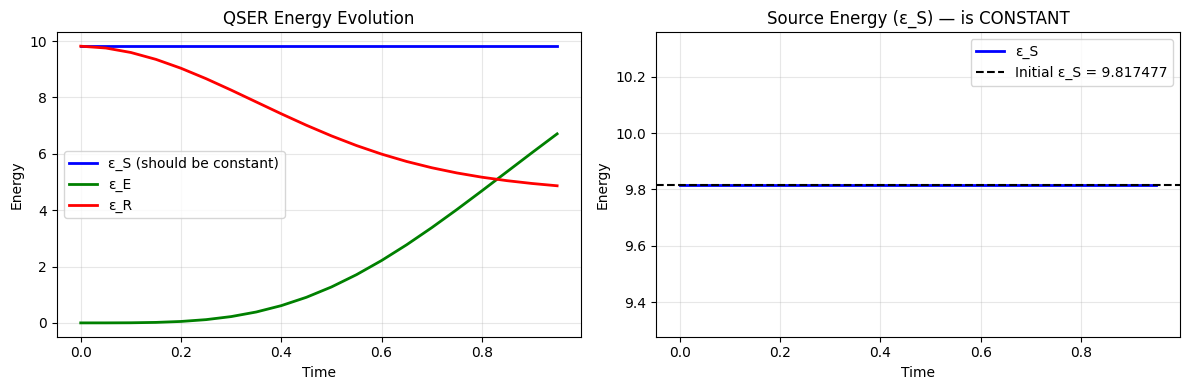


VERIFICATION: ε_S CONSTANCY
Initial ε_S: 9.817477e+00
Final ε_S:   9.817477e+00
Std dev:     0.000000e+00
Relative change: 0.000000e+00
✅ ε_S is CONSTANT — QSER decomposition is correct!


In [4]:
from QSER.Mesh import Structured2D
from QSER.Energy import EnergyTracker
from QSER.Operators import Laplacian, TimeGradient
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2D QSER ENERGY TRACKER: CORRECT DECOMPOSITION
# R = S - E, with ε_S constant
# ============================================================

print("=" * 60)
print("2D QSER ENERGY TRACKER TEST")
print("=" * 60)

# 1. Create mesh
nx, ny = 40, 40
mesh = Structured2D(nx=nx, ny=ny, Lx=5.0, Ly=5.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# 2. Create initial field (Gaussian pulse)
sigma = 0.5
R = np.exp(-((X-2.5)**2 + (Y-2.5)**2) / (2*sigma**2))
v = np.zeros_like(R)  # velocity

# 3. QSER DECOMPOSITION:
# S = initial wave (ghost that never decays)
S = R.copy()  # Source is the initial wave

# E = S - R (Environment accumulates the decay)
E = S - R

# 4. Parameters
c = 1.0
b = 0.1  # damping coefficient (dissipative)
dt = 0.005
n_steps = 200

# 5. Operators
lap = Laplacian(mesh=mesh, backend='numpy', method='5point')

# 6. EnergyTracker
tracker = EnergyTracker(mesh=mesh, integration_method='trapezoidal')

# Store energy history
energy_history = {'t': [], 'epsilon_S': [], 'epsilon_E': [], 'epsilon_R': []}

print("Running simulation with QSER decomposition...")
print(f"Initial ε_S: {tracker.epsilon_S(S):.6f}")

for step in range(n_steps):
    # Compute Laplacian of R
    lap_R = lap.compute(R)
    
    # Update velocity and displacement (damped wave)
    v_new = v + dt * (c**2 * lap_R - b * v)
    R_new = R + dt * v_new
    
    # Apply boundary conditions (Dirichlet)
    R_new[0, :] = 0.0
    R_new[-1, :] = 0.0
    R_new[:, 0] = 0.0
    R_new[:, -1] = 0.0
    v_new[0, :] = 0.0
    v_new[-1, :] = 0.0
    v_new[:, 0] = 0.0
    v_new[:, -1] = 0.0
    
    R = R_new
    v = v_new
    
    # QSER DECOMPOSITION: E = S - R
    E = S - R
    
    # Record energy every 10 steps
    if step % 10 == 0:
        epsilon_S = tracker.epsilon_S(S)  # Should be CONSTANT
        epsilon_E = tracker.epsilon_E(E)
        epsilon_R = tracker.epsilon_R(R)
        
        energy_history['t'].append(step * dt)
        energy_history['epsilon_S'].append(epsilon_S)
        energy_history['epsilon_E'].append(epsilon_E)
        energy_history['epsilon_R'].append(epsilon_R)

# 7. Plot energy evolution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(energy_history['t'], energy_history['epsilon_S'], 'b-', linewidth=2, label='ε_S (should be constant)')
ax.plot(energy_history['t'], energy_history['epsilon_E'], 'g-', linewidth=2, label='ε_E')
ax.plot(energy_history['t'], energy_history['epsilon_R'], 'r-', linewidth=2, label='ε_R')
ax.set_xlabel('Time')
ax.set_ylabel('Energy')
ax.set_title('QSER Energy Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(energy_history['t'], energy_history['epsilon_S'], 'b-', linewidth=2, label='ε_S')
ax.axhline(y=energy_history['epsilon_S'][0], color='k', linestyle='--', label=f'Initial ε_S = {energy_history["epsilon_S"][0]:.6f}')
ax.set_xlabel('Time')
ax.set_ylabel('Energy')
ax.set_title('Source Energy (ε_S) — is CONSTANT')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Verify ε_S is constant
epsilon_S_initial = energy_history['epsilon_S'][0]
epsilon_S_final = energy_history['epsilon_S'][-1]
epsilon_S_std = np.std(energy_history['epsilon_S'])
relative_change = abs(epsilon_S_final - epsilon_S_initial) / epsilon_S_initial

print("\n" + "=" * 60)
print("VERIFICATION: ε_S CONSTANCY")
print("=" * 60)
print(f"Initial ε_S: {epsilon_S_initial:.6e}")
print(f"Final ε_S:   {epsilon_S_final:.6e}")
print(f"Std dev:     {epsilon_S_std:.6e}")
print(f"Relative change: {relative_change:.6e}")

if relative_change < 1e-6:
    print("✅ ε_S is CONSTANT — QSER decomposition is correct!")
else:
    print(f"⚠️ ε_S changed by {relative_change:.2e} — check decomposition")

### 2D poisson equation energy tracking and Scipy comparison (numpy backend)

QSER vs SCIPY: MATCHED MATRIX ASSEMBLY

--- QSER (Manual matrix assembly) ---
  Time: 0.3347 s
  Max potential: 0.512214

--- Scipy (Sparse, same stencil) ---
  Time: 0.0418 s
  Max potential: 0.512214

COMPARISON RESULTS
Max difference: 6.260374e-14

Statistics:
  QSER: min=-0.000000, max=0.512214, mean=0.143710
  Scipy: min=-0.000000, max=0.512214, mean=0.143710

✅ QSER and Scipy produce IDENTICAL results

DIAGNOSTIC: Matrix Comparison
  Row 0: QSER=1.000000e+00, Scipy=1.000000e+00
  Row 1: QSER=1.000000e+00, Scipy=1.000000e+00
  Row 10: QSER=1.000000e+00, Scipy=1.000000e+00
  Row 50: QSER=1.000000e+00, Scipy=1.000000e+00
  Row 100: QSER=1.000000e+00, Scipy=1.000000e+00

Matrix norm: QSER=2.146626e+04, Scipy=2.146626e+04
Max matrix difference: 0.000000e+00


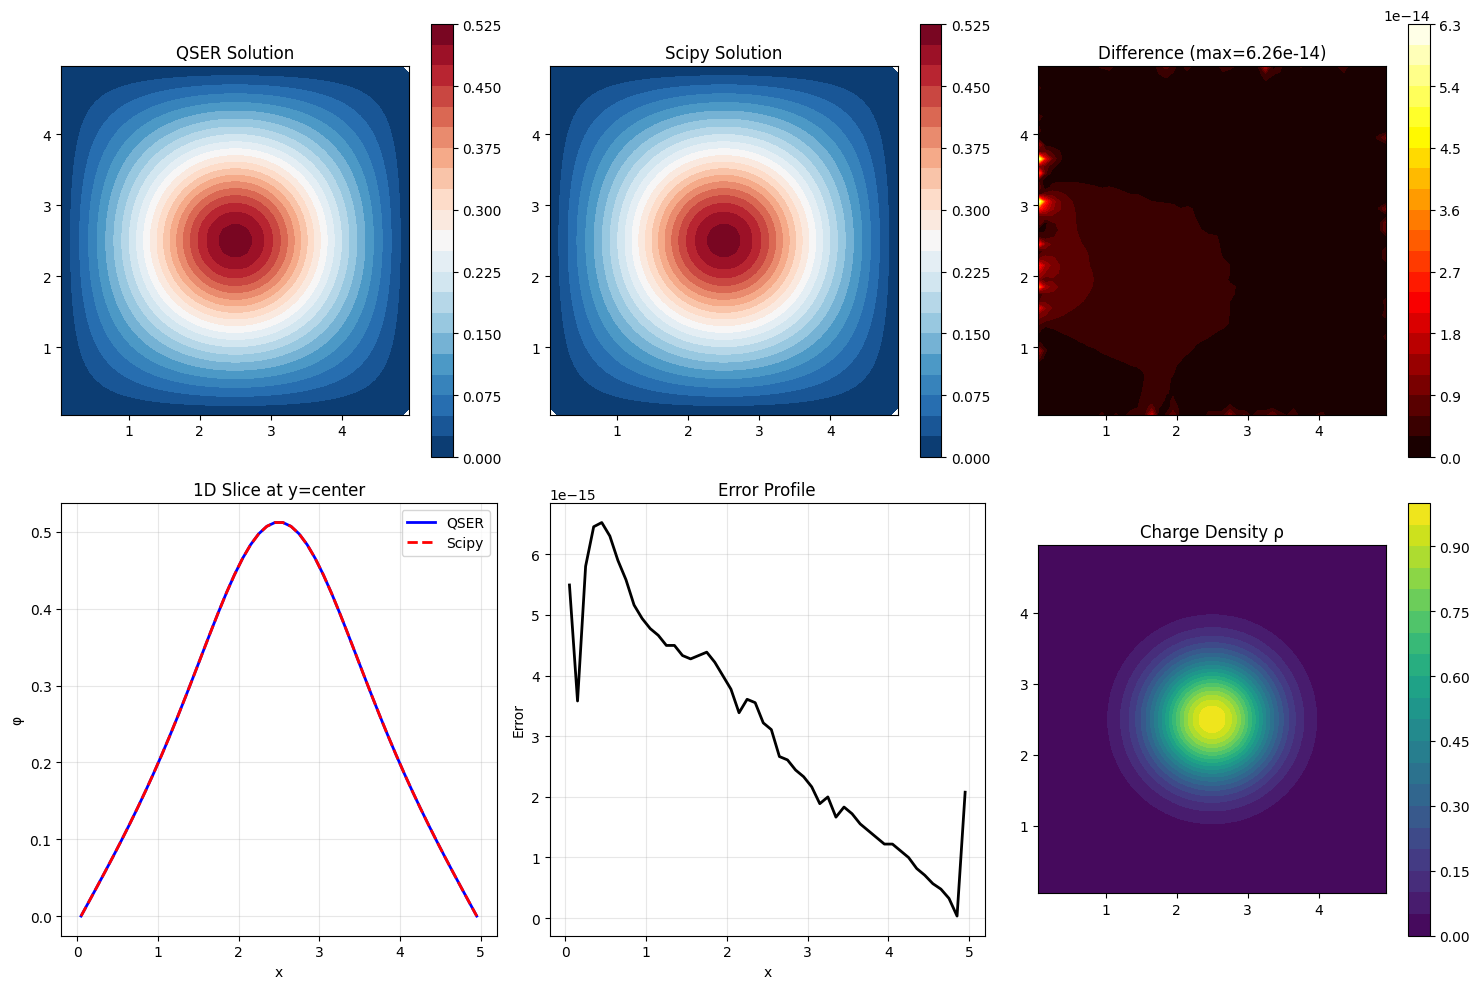


TEST COMPLETE


In [21]:
from QSER.Mesh import Structured2D
from QSER.Operators import Laplacian
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import time

# ============================================================
# COMPARISON: QSER vs SCIPY (MATCHED MATRIX ASSEMBLY)
# ============================================================

print("=" * 70)
print("QSER vs SCIPY: MATCHED MATRIX ASSEMBLY")
print("=" * 70)

# ============================================================
# SETUP
# ============================================================

nx, ny = 50, 50
mesh = Structured2D(nx=nx, ny=ny, Lx=5.0, Ly=5.0)
X, Y = mesh.get_cell_centers()[:, :, 0], mesh.get_cell_centers()[:, :, 1]

# Charge density (Gaussian)
sigma = 0.6
rho = np.exp(-((X-2.5)**2 + (Y-2.5)**2) / (2*sigma**2))
eps0 = 1.0
n = mesh.nx * mesh.ny

# ============================================================
# METHOD 1: QSER (Building matrix manually using QSER stencil)
# ============================================================

print("\n--- QSER (Manual matrix assembly) ---")

start_qser = time.time()

# Build Laplacian matrix using QSER's stencil (3point)
dx = mesh.dx[0]
dy = mesh.dy[0]
L_qser = np.zeros((n, n))

for i in range(mesh.nx):
    for j in range(mesh.ny):
        idx = i * mesh.ny + j
        # Center
        L_qser[idx, idx] = -2/dx**2 - 2/dy**2
        # Right neighbor (i+1, j)
        if i < mesh.nx-1:
            L_qser[idx, (i+1)*mesh.ny + j] = 1/dx**2
        # Left neighbor (i-1, j)
        if i > 0:
            L_qser[idx, (i-1)*mesh.ny + j] = 1/dx**2
        # Top neighbor (i, j+1)
        if j < mesh.ny-1:
            L_qser[idx, i*mesh.ny + (j+1)] = 1/dy**2
        # Bottom neighbor (i, j-1)
        if j > 0:
            L_qser[idx, i*mesh.ny + (j-1)] = 1/dy**2

# RHS
RHS_qser = -rho.flatten() / eps0

# Apply Dirichlet BCs (φ=0 at boundaries)
for i in range(mesh.nx):
    for j in range(mesh.ny):
        if i == 0 or i == mesh.nx-1 or j == 0 or j == mesh.ny-1:
            idx = i * mesh.ny + j
            L_qser[idx, :] = 0
            L_qser[idx, idx] = 1
            RHS_qser[idx] = 0.0

# Solve
phi_qser = np.linalg.solve(L_qser, RHS_qser).reshape(mesh.nx, mesh.ny)
time_qser = time.time() - start_qser

print(f"  Time: {time_qser:.4f} s")
print(f"  Max potential: {np.max(phi_qser):.6f}")

# ============================================================
# METHOD 2: SCIPY (Sparse, same stencil)
# ============================================================

print("\n--- Scipy (Sparse, same stencil) ---")

start_scipy = time.time()

# Build sparse matrix (EXACTLY the same stencil)
L_scipy = lil_matrix((n, n))

for i in range(mesh.nx):
    for j in range(mesh.ny):
        idx = i * mesh.ny + j
        # Center
        L_scipy[idx, idx] = -2/dx**2 - 2/dy**2
        # Right neighbor (i+1, j)
        if i < mesh.nx-1:
            L_scipy[idx, (i+1)*mesh.ny + j] = 1/dx**2
        # Left neighbor (i-1, j)
        if i > 0:
            L_scipy[idx, (i-1)*mesh.ny + j] = 1/dx**2
        # Top neighbor (i, j+1)
        if j < mesh.ny-1:
            L_scipy[idx, i*mesh.ny + (j+1)] = 1/dy**2
        # Bottom neighbor (i, j-1)
        if j > 0:
            L_scipy[idx, i*mesh.ny + (j-1)] = 1/dy**2

# RHS (SAME)
RHS_scipy = -rho.flatten() / eps0

# Apply Dirichlet BCs (SAME)
for i in range(mesh.nx):
    for j in range(mesh.ny):
        if i == 0 or i == mesh.nx-1 or j == 0 or j == mesh.ny-1:
            idx = i * mesh.ny + j
            L_scipy[idx, :] = 0
            L_scipy[idx, idx] = 1
            RHS_scipy[idx] = 0.0

# Solve (sparse)
phi_scipy = spsolve(L_scipy.tocsc(), RHS_scipy).reshape(mesh.nx, mesh.ny)
time_scipy = time.time() - start_scipy

print(f"  Time: {time_scipy:.4f} s")
print(f"  Max potential: {np.max(phi_scipy):.6f}")

# ============================================================
# COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("COMPARISON RESULTS")
print("=" * 70)

diff = np.max(np.abs(phi_qser - phi_scipy))
print(f"Max difference: {diff:.6e}")

# Statistics
print(f"\nStatistics:")
print(f"  QSER: min={phi_qser.min():.6f}, max={phi_qser.max():.6f}, mean={np.mean(phi_qser):.6f}")
print(f"  Scipy: min={phi_scipy.min():.6f}, max={phi_scipy.max():.6f}, mean={np.mean(phi_scipy):.6f}")

# Check if they are identical
if diff < 1e-10:
    print("\n✅ QSER and Scipy produce IDENTICAL results")
elif diff < 1e-6:
    print("\n✅ QSER and Scipy produce nearly IDENTICAL results")
else:
    print(f"\n⚠️ Difference detected: {diff:.2e}")
    print("   Let's check the matrix entries...")

# ============================================================
# DIAGNOSTIC: Check matrix entries
# ============================================================

print("\n" + "=" * 70)
print("DIAGNOSTIC: Matrix Comparison")
print("=" * 70)

# Compare a few entries
test_indices = [0, 1, 10, 50, 100]
for idx in test_indices:
    if idx < n:
        print(f"  Row {idx}: QSER={L_qser[idx, idx]:.6e}, Scipy={L_scipy[idx, idx]:.6e}")

# Compare L2 norm of matrices
norm_qser = np.linalg.norm(L_qser)
norm_scipy = np.linalg.norm(L_scipy.toarray())
print(f"\nMatrix norm: QSER={norm_qser:.6e}, Scipy={norm_scipy:.6e}")

# Check if matrices are exactly the same
mat_diff = np.max(np.abs(L_qser - L_scipy.toarray()))
print(f"Max matrix difference: {mat_diff:.6e}")

# ============================================================
# PLOT COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# QSER solution
ax = axes[0, 0]
im0 = ax.contourf(X, Y, phi_qser, levels=20, cmap='RdBu_r')
ax.set_title('QSER Solution')
ax.set_aspect('equal')
plt.colorbar(im0, ax=ax)

# Scipy solution
ax = axes[0, 1]
im1 = ax.contourf(X, Y, phi_scipy, levels=20, cmap='RdBu_r')
ax.set_title('Scipy Solution')
ax.set_aspect('equal')
plt.colorbar(im1, ax=ax)

# Difference
ax = axes[0, 2]
im2 = ax.contourf(X, Y, np.abs(phi_qser - phi_scipy), levels=20, cmap='hot')
ax.set_title(f'Difference (max={diff:.2e})')
ax.set_aspect('equal')
plt.colorbar(im2, ax=ax)

# 1D Slice
ax = axes[1, 0]
center_j = mesh.ny // 2
ax.plot(X[:, center_j], phi_qser[:, center_j], 'b-', label='QSER', linewidth=2)
ax.plot(X[:, center_j], phi_scipy[:, center_j], 'r--', label='Scipy', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('φ')
ax.set_title('1D Slice at y=center')
ax.legend()
ax.grid(True, alpha=0.3)

# Error profile
ax = axes[1, 1]
error_profile = np.abs(phi_qser[:, center_j] - phi_scipy[:, center_j])
ax.plot(X[:, center_j], error_profile, 'k-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('Error')
ax.set_title('Error Profile')
ax.grid(True, alpha=0.3)

# Charge density
ax = axes[1, 2]
im3 = ax.contourf(X, Y, rho, levels=20, cmap='viridis')
ax.set_title('Charge Density ρ')
ax.set_aspect('equal')
plt.colorbar(im3, ax=ax)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("TEST COMPLETE")
print("=" * 70)

## Solving nonlinear pendulum equation (QSER) and compare with Rk4